Mums ir dots tiešsaistes straumēšanas uzņēmums ar vairāk nekā 100,000 lietotāju, kas piedāvā filmas un seriālus. 
Mēs vēlamies prognozēt, vai lietotājs atcels savu abonementu nākamā mēneša laikā. Ja spēsim savlaicīgi identificēt šādus lietotājus, varēsim piedāvāt personalizētus piedāvājumus un samazināt klientu aizplūšanu.

Jā, datos ir kolonna "Churn" (Jā/Nē), kas norāda, vai lietotājs atcēla abonementu.
Mēs gribam prognozēt atbildi katram jaunam lietotājam.
Tas ir SUPERVISED LEARNING.
Apakštips: CLASSIFICATION (Jā/Nē atbilde).

Target: Churn (Jā = atcēla abonementu, Nē = palika)
Features (ievades mainīgie):
Skaitliski: Watch_Time_Hours, Login_Frequency, Subscription_Length, Avg_Daily_Usage
Kategorisks: Subscription_Type, Device_Type, Country, Payment_Method

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")

✓ Visas bibliotēkas ielādētas veiksmīgi


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopu forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
print(df.head())

Datu kopu forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0

In [4]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)

Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


In [5]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
print(df.describe())

Skaitlisko kolonnu statistika:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%          

In [6]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())

Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [7]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kategoriskās kolonnas: {cat_cols}")

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']


C:\Users\VlaO\AppData\Local\Temp\ipykernel_32656\1917500086.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


In [8]:
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")
print(df['Revenue'].value_counts())
print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")

Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


In [9]:
# Kuras kolonnas satur trūkstošas vērtības? 
missing = df.isnull().sum() 
missing = missing[missing > 0].sort_values(ascending=False) 

print("Kolonnas ar trūkstošām vērtībām:") 
print(missing)

Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)


In [10]:
# Vizualizācija
if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='barh', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.xlabel('Trūkstošo vērtību skaits')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Trūkstošo vērtību nav — dati ir tīri!")

✓ Trūkstošo vērtību nav — dati ir tīri!


In [11]:
# Skaitliskām kolonnām — mediāna
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")

In [12]:
# Kategoriskām kolonnām — moda
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✓ {col}: aizpildīts ar modu '{mode_val}'")

# Galīgā pārbaude
assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("\n✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() =", df.isnull().sum().sum())


✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = 0


C:\Users\VlaO\AppData\Local\Temp\ipykernel_32656\4207485707.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


Skaitliskajām kolonnām izmantoju mediānu, jo tā labāk apstrādā novirzes.
Kategoriskajām kolonnām izmantoju modu (biežāko vērtību), jo tā saglabā datu sadalījumu. 
DataShop datu kopā nav trūkstošo vērtību, taču šo metodi izmantošu nākamajos projektos ar reāliem datiem.

In [13]:
# Kādas ir kategoriskās kolonnas?
print("Kategoriskās kolonnas:")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
    print(df[col].unique()[:10])  # Parāda pirmos 10

Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

VisitorType: 3 unikālas vērtības
<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]


C:\Users\VlaO\AppData\Local\Temp\ipykernel_32656\1312651712.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


In [14]:
# Boolean/binary kolonnas — Label Encoding
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print("✓ Boolean kolonnas konvertētas uz 0/1")

✓ Boolean kolonnas konvertētas uz 0/1


In [15]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
print(f"✓ One-Hot Encoding pabeigts. Jaunas kolonnas: {df.shape[1]}")
print("Nākamās jaunās kolonnas:")
print(df.columns[df.columns.str.contains('Month|VisitorType')])

✓ One-Hot Encoding pabeigts. Jaunas kolonnas: 27
Nākamās jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='str')


In [16]:
# Pārliecinies, ka nav palikušas neapstrādātas kategoriskās kolonnas
remaining_cat = df.select_dtypes(include=['object', 'string']).columns.tolist()
assert len(remaining_cat) == 0, f"Vēl neapstrādātas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas. Atlikt: ", len(remaining_cat))

# Visas kolonnas tagad ir skaitliskas
print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")
print("Dati tipi:")
print(df.dtypes.value_counts())

✓ Visas kategoriskās kolonnas kodētas. Atlikt:  0

Kolonnu skaits pēc kodēšanas: 27
Dati tipi:
bool       11
int64       9
float64     7
Name: count, dtype: int64


Izmantoju Label Encoding boolean kolonnām (Weekend, Revenue), jo ir tikai 2 vērtības.
Izmantoju One-Hot Encoding Month un VisitorType kolonnām, jo ir vairākas kategorijas.
One-Hot Encoding paplašina datu matricu, bet ļauj algoritmiem labāk izprast kategorijas neveidojot relācijas.

In [17]:
# Kādas ir skaitliskās kolonnas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")
print(numeric_cols[:10])  # Parāda pirmos 10

# Statistika PIRMS normalizācijas
print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")
print(df[numeric_cols[:6]].describe().round(2))

Skaitliskās kolonnas (16 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00                    93.26           0.00   
max             27.00                  3398.75          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
me

In [18]:
from sklearn.preprocessing import StandardScaler

# Atlasi skaļošanai VISAS skaitliskās kolonnas (izņemot target)
cols_to_scale = [col for col in numeric_cols if col != 'Revenue']

# StandardScaler: (x - mean) / std
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"✓ {len(cols_to_scale)} skaitliskās kolonnas normalizētas")
print("\n=== STATISTIKA PĒC NORMALIZĀCIJAS ===")
print(df[cols_to_scale[:6]].describe().round(2))

✓ 15 skaitliskās kolonnas normalizētas

=== STATISTIKA PĒC NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00        12330.0   
mean            -0.00                     0.00           -0.0   
std              1.00                     1.00            1.0   
min             -0.70                    -0.46           -0.4   
25%             -0.70                    -0.46           -0.4   
50%             -0.40                    -0.41           -0.4   
75%              0.51                     0.07           -0.4   
max              7.43                    18.77           18.5   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    -0.00            0.00                    -0.00  
std                      1.00            1.00                     1.00  
min                     -0.24           -0.7

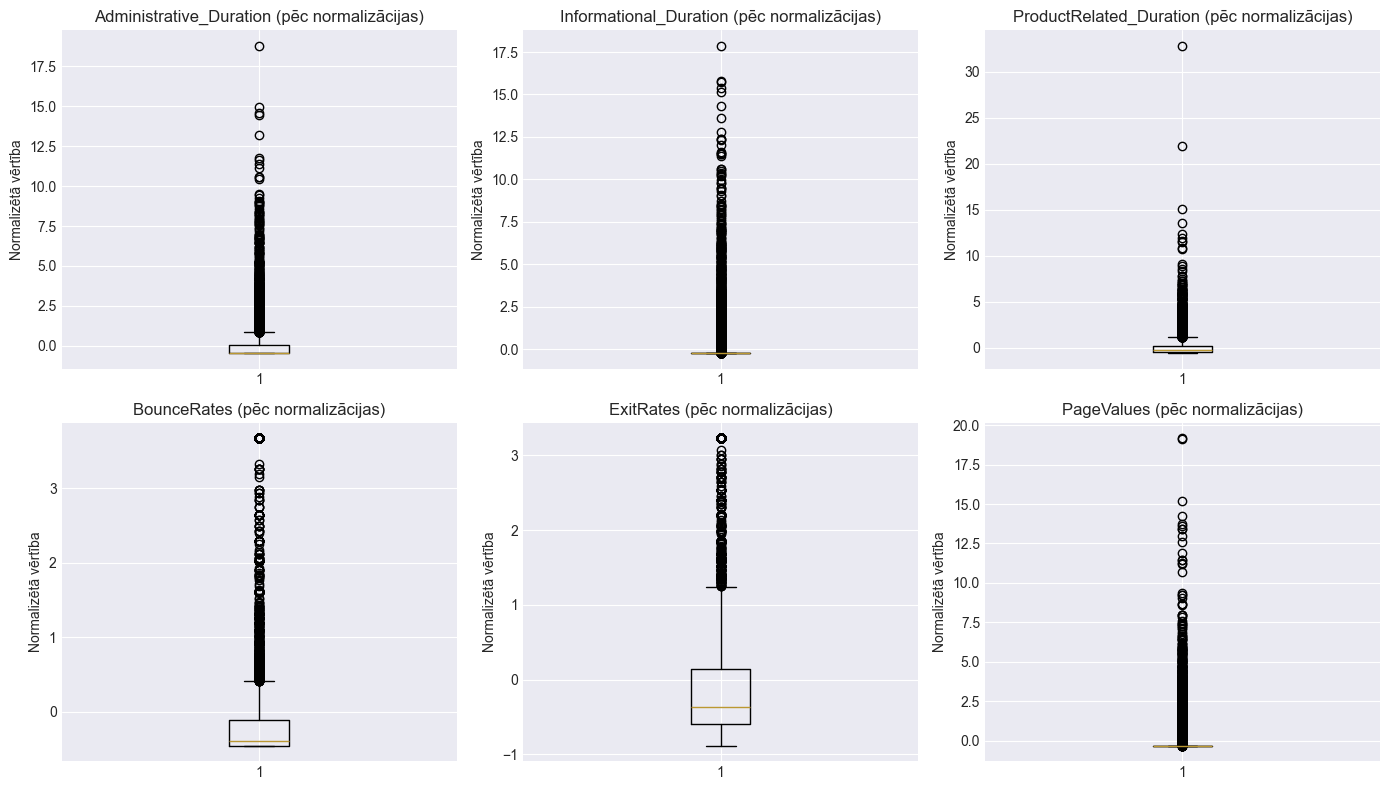

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [19]:
# Salīdzinājums:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
               'BounceRates', 'ExitRates', 'PageValues']

for idx, col in enumerate(sample_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} (pēc normalizācijas)')
        axes[idx].set_ylabel('Normalizētā vērtība')

plt.tight_layout()
plt.show()

print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")

In [20]:
# Kopējais laiks vietnē (visu sadaļu laiki summēti)
df['TotalDuration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

print("✓ Jaunas iezīmes izveidotas")
print(f"Datu kopas forma tagad: {df.shape}")

✓ Jaunas iezīmes izveidotas
Datu kopas forma tagad: (12330, 28)


**Ko nozīmē jaunā iezīme?**
TotalDuration ir kopējais laiks (sekundēs), ko apmeklētājs pavadīja vietnē — administratīvajās, informācijas un produktu lapās kopā. 
Biznesa valodā: cik ilgi klients "pārlūkoja" veikalu.

**Kāpēc tā ir noderīga ML modelim?**
Atsevišķas kolonnas parāda laiku katrai sadaļai, bet modelis var labāk redzēt kopējo iesaisti, ja tas ir viens skaitlis. 
Intuitīvi: klients, kurš pavada vairāk laika, biežāk veic pirkumu.

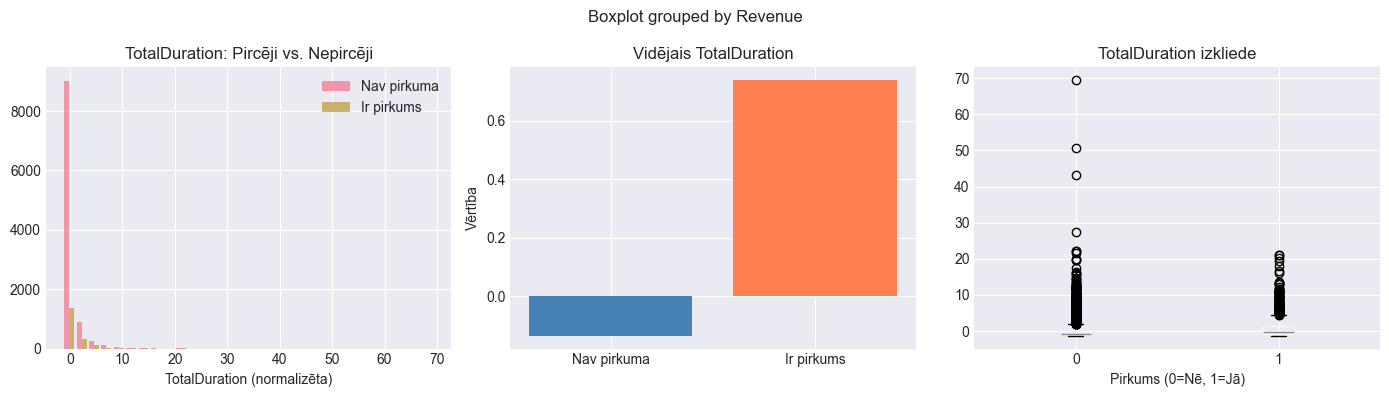

✓ Jaunā iezīme analizēta un vizualizēta


In [21]:
# Salīdzinājums: jaunā iezīme starp pircējiem un nepircējiem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Piemērs ar TotalDuration (aprēķins ir redzams slaidos)
axes[0].hist([df[df['Revenue'] == 0]['TotalDuration'],
              df[df['Revenue'] == 1]['TotalDuration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('TotalDuration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('TotalDuration (normalizēta)')
axes[0].legend()

# Vidējie
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['TotalDuration'].mean(),
            df[df['Revenue'] == 1]['TotalDuration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais TotalDuration')
axes[1].set_ylabel('Vērtība')

# Box plot
df.boxplot(column='TotalDuration', by='Revenue', ax=axes[2])
axes[2].set_title('TotalDuration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")

In [22]:
# Saglabā tīro datu kopu nākamajajiem uzdevumiem
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")

✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 28


In [23]:
# Pārbaudi, vai fails ir nolasāms
df_check = pd.read_csv(output_path)
print(f"✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās rindas:")
print(df_check.head(2))

✓ Fails pārbaudīts: (12330, 28)
Pirmās rindas:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.691003                -0.624348   
1               -0.244931       -0.668518                -0.590903   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Jul  Month_June  \
0     3.667189   3.229316   -0.317178   -0.308821  ...      False       False   
1    -0.457683   1.171473   -0.317178   -0.308821  ...      False       False   

   Month_Mar  Month_May  Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0      False      False      False      False      False              False   
1      False      False      False      False      False              False   

   VisitorType_Returning_Visitor  TotalDuration  
0                         

## Datu sagatavošanas rezumējums

### Identificētās problēmas:
- Datu kopā nebija trūkstošo vērtību (df.isnull().sum().sum() = 0)
- 3 kategoriskās kolonnas (Month, VisitorType, Weekend) nebija piemērotas ML algoritmiem
- Skaitliskās kolonnas bija dažādos mērogos (piemēram, PageValues 0–361, BounceRates 0–0.2)
- Trūka iezīmju, kas apkopotu apmeklētāja kopējo uzvedību

### Veiktās darbības:
1. Trūkstošās vērtības — skaitliskajām kolonnām aizpildīts ar mediānu, kategoriskajām ar modu (šajā gadījumā nebija nepieciešams)
2. Kategorisko mainīgo kodēšana — Weekend un Revenue → Label Encoding (0/1); Month un VisitorType → One-Hot Encoding
3. Normalizācija — visas skaitliskās kolonnas (izņemot Revenue) apstrādātas ar StandardScaler (vidējā ≈ 0, std ≈ 1)
4. Feature engineering — izveidota jauna iezīme TotalDuration (Administrative_Duration + Informational_Duration + ProductRelated_Duration)

### Rezultāts:
- Sākotnējās kolonnas: 18 → Pēc apstrādes: 28 (One-Hot Encoding pievienoja jaunas kolonnas)
- Visas kolonnas ir skaitliskas, nav object vai bool tipu
- Datu kopa saglabāta failā shoppers_clean.csv un gatava ML modeļu trenēšanai

In [24]:
# Ielādē tikko sagatavoto tīro datu kopu
df = pd.read_csv('shoppers_clean.csv')

# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā:\n{y_train.value_counts(normalize=True).round(3)}")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


## Kāpēc stratify=y?

Datu kopā pirkumi ir tikai ~15% no visām sesijām — tas ir **nesabalansēts sadalījums**.
Bez `stratify=y` pastāv risks, ka testa kopā nejauši nonāk, piemēram, tikai 8% pircēju,
bet treniņa kopā 17%. Tad modelis trenējas uz citāda sadalījuma nekā testē, un rezultāti
ir maldinoši. `stratify=y` garantē, ka abās kopās ir vienāds pircēju īpatsvars (~15%).

## Kāpēc 80/20 sadalījums?

80% treniņam dod modelim pietiekami daudz piemēru, lai iemācītos likumsakarības
(~9 800 sesijas). 20% testam (~2 500 sesijas) ir pietiekami daudz, lai iegūtu
ticamu novērtējumu par to, kā modelis darbosies uz jauniem datiem. Ar šādu datu
kopu (12 330 rindas) 80/20 ir standarta, saprātīga izvēle — ja datu būtu ļoti maz,
varētu apsvērt 90/10 vai krusteniskās validācijas metodes.

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))

=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



In [29]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))

            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.635258
Logistic Regression  0.482270


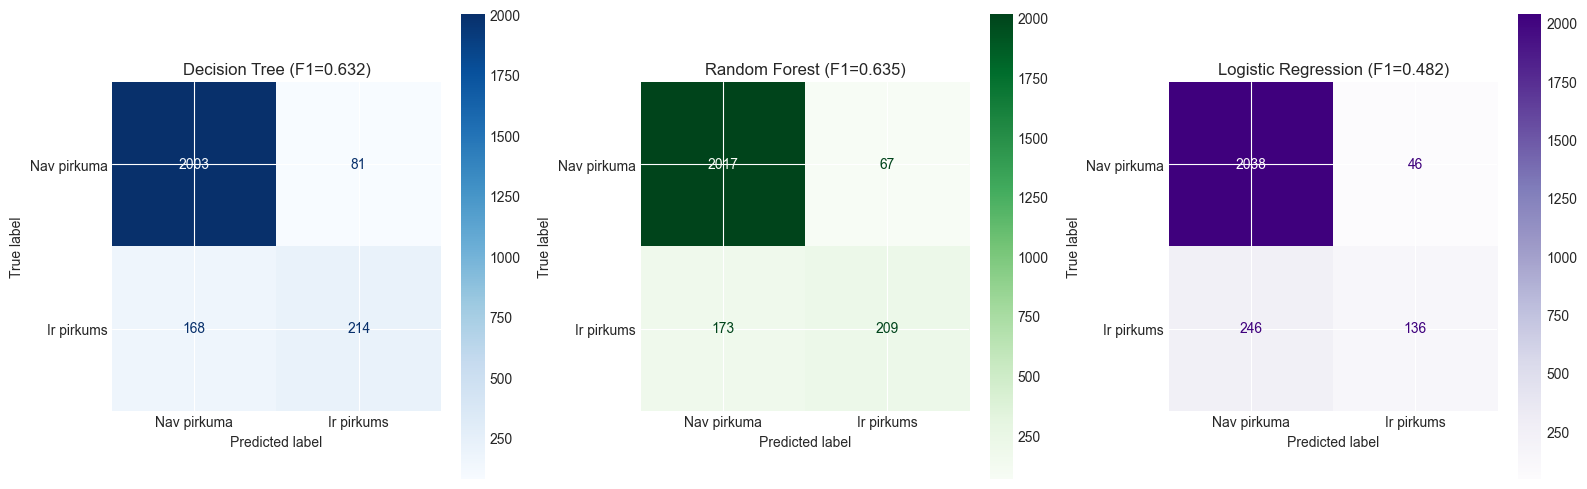

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()

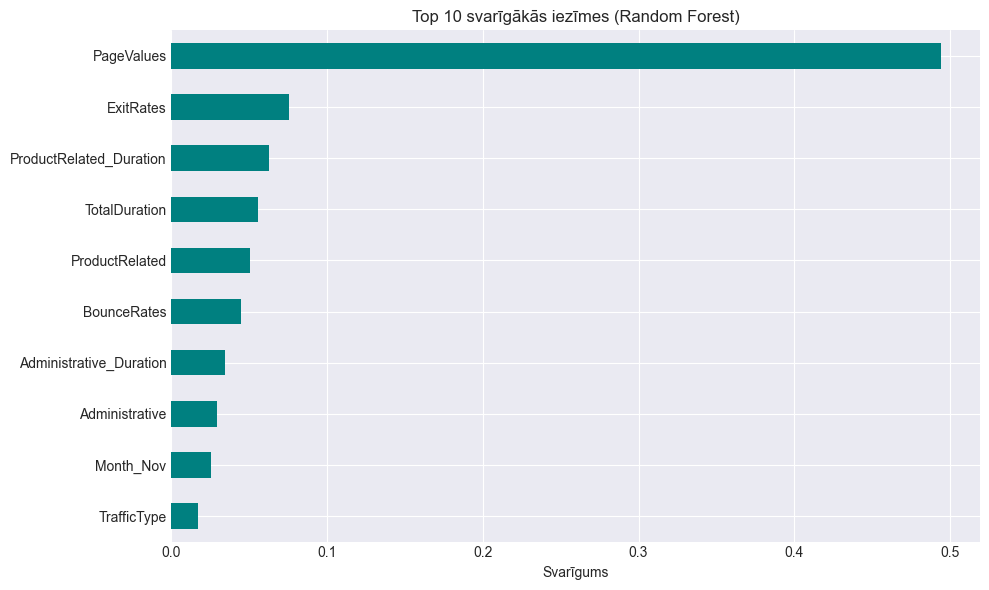

In [31]:
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Secinājumi

### Modeļu salīdzinājums
Vislabāko rezultātu uzrādīja **Random Forest** ar F1 score = 0.635258, apsteidzot Decision Tree (0.632201) un Logistic Regression (0.482270).
Random Forest ir spēcīgāks, jo tas apvieno daudzu lēmumu koku prognozes, tādejādi samazinot pārmācīšanās risku, kas raksturīgs vienam Decision Tree.
Logistic Regression uzrādīja zemāko rezultātu, jo datu atkarības, visticamāk, nav lineāras.

### Kāpēc F1 score, nevis accuracy?
Šajā datu kopā tikai ~15% sesiju beidzas ar pirkumu — tas ir nesabalansēts sadalījums. Modelis, kas VIENMĒR prognozē "nav pirkuma", sasniegs ~85% accuracy, bet būs pilnīgi bezjēdzīgs biznesam. F1 score ņem vērā gan precision (cik no prognozētajiem pircējiem tiešām pirka), gan recall (cik no īstajiem pircējiem modelis atrada), tāpēc tas ir daudz godīgāks rādītājs šeit.

### Svarīgākās iezīmes
Feature importance grafiks skaidri parāda, ka dominējošā iezīme ir **PageValues** — tā pārsniedz pārējās iezīmes vairākkārt. Tas ir loģiski: PageValues mēra lapu vērtību tieši pirms pirkuma pabeigšanas, tāpēc tā tieši atspoguļo pirkuma nodomu. Otrā svarīgākā ir **ExitRates** — augsta vērtība nozīmē, ka klients "aiziet", neveicot pirkumu. Ievērojami, ka mūsu izveidotā iezīme **TotalDuration** iekļuva top 4, apsteidzot ProductRelated, BounceRates un citas — tas apstiprina, ka kopējais laiks vietnē ir noderīgs pirkuma uzvedības signāls.